# 04. Multivariate EDA, Correlations & Interaction Discovery

How to detect multicollinearity, avoid Simpson's Paradox, and uncover multi-feature interaction effects using pure Scikit-Learn and NumPy.


## 1. Objective
Master multivariate exploratory techniques:
1. Distinguish between linear (Pearson) and rank (Spearman) correlations.
2. Identify **multicollinearity** and compute **Variance Inflation Factors (VIF)**.
3. Discover **interaction effects** where the effect of Feature A depends on Feature B.


## 2. Dataset & Decision Context
- **Dataset**: Employee Workforce & Attrition (`employee_attrition.csv`)
- **ML Objective**: Binary Classification for `attrition`
- **Features**: `years_at_company`, `years_in_role`, `salary`, `satisfaction_score`, `overtime`, `age`


## 3. What Should I Check?

| Multivariate Check | Why It Matters | Downstream Action |
|---|---|---|
| **Pairwise Correlation Matrix** | Spot highly redundant feature pairs ($|r| > 0.80$) | Drop one feature or create ratio/difference |
| **Variance Inflation Factor (VIF)** | Quantifies collinearity severity for linear/logistic models | Drop features with VIF $> 5.0$ to stabilize coefficients |
| **Interaction / Conditional Effects** | Two features may only predict target when combined | Engineer explicit multiplicative interaction terms |
| **Simpson's Paradox** | Group aggregations can reverse apparent overall correlations | Stratify analysis by confounding category (e.g. department) |


## 4. Technique Breakdown

```
WHAT: Multivariate Correlation Matrix, VIF Analysis, and Interaction Grids
WHY: Collinear features inflate standard errors in linear models; uncaptured interactions hurt tree depth
WHEN: Before final feature selection and pipeline construction
WHEN NOT: Do not rely solely on Pearson correlation for non-linear or ordinal data
HOW: Compare Pearson vs Spearman, compute VIF via linear regressions, plot FacetGrid interaction plots
WHAT TO LOOK FOR: VIF > 5.0, divergent Pearson vs Spearman values, crossing slope lines in interaction plots
WHAT ACTION: Create composite ratio features; drop redundant raw variables; add interaction terms
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

df = pd.read_csv('../datasets/workforce/employee_attrition.csv')
print(f"Workforce Dataset: {df.shape[0]:,} rows | Attrition Rate: {df['attrition'].mean():.2%}")
df.head()


Workforce Dataset: 16,000 rows | Attrition Rate: 18.73%


,employee_id,age,department,job_role,salary,years_at_company,years_in_role,overtime,satisfaction_score,commute_distance,promotion_count,training_hours,performance_score,attrition
0,EMP_00001,40,Engineering,DevOps Specialist,118600,4,1,No,3,NaN,0,20.0,2,0
1,EMP_00002,34,Sales,Account Executive,102200,3,1,No,2,6.0,0,45.0,3,0
2,EMP_00003,31,Engineering,Tech Lead,157800,0,0,No,3,3.9,0,50.0,1,0
3,EMP_00004,26,Sales,Account Executive,120500,4,1,Yes,5,31.9,1,30.0,4,0
4,EMP_00005,22,Engineering,DevOps Specialist,105200,2,1,Yes,3,18.8,0,19.0,2,1


## 5. Pearson vs Spearman Correlation Matrix


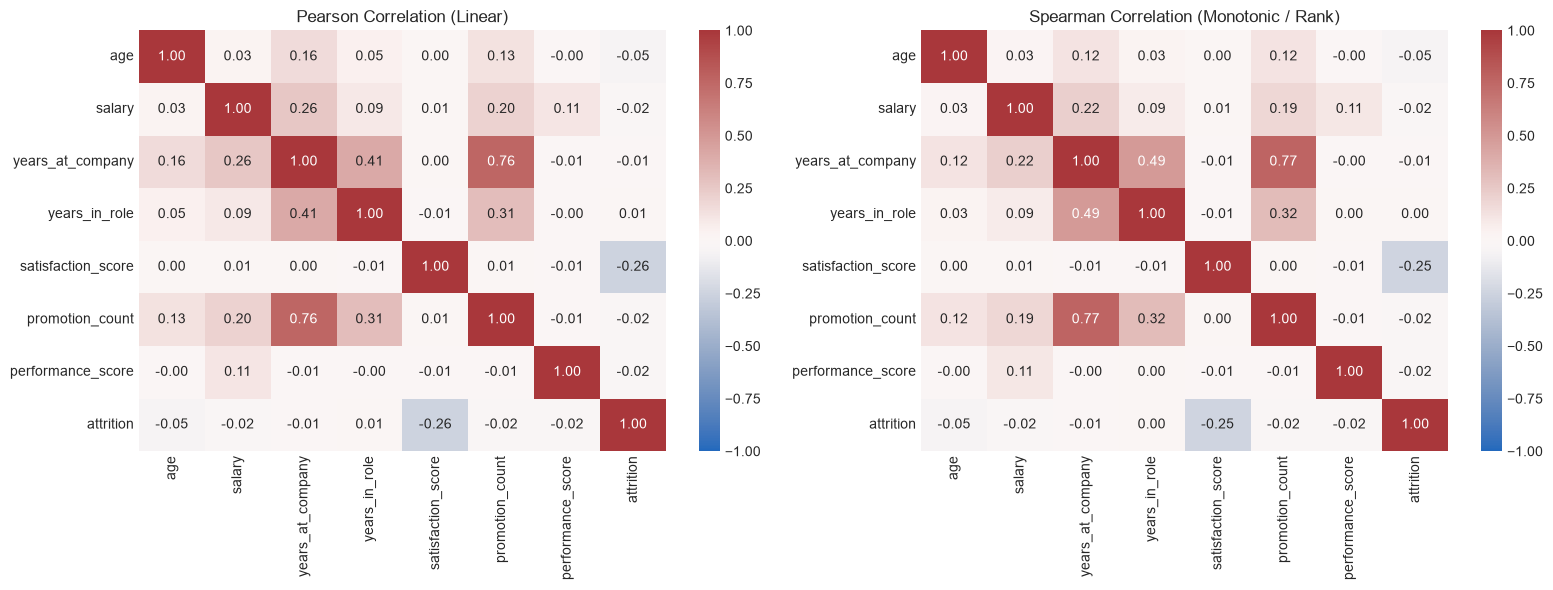

In [2]:
num_cols = ['age', 'salary', 'years_at_company', 'years_in_role', 'satisfaction_score', 'promotion_count', 'performance_score', 'attrition']
corr_pearson = df[num_cols].corr(method='pearson')
corr_spearman = df[num_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation (Linear)')

sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation (Monotonic / Rank)')

plt.tight_layout()
plt.show()


## 6. Multicollinearity & Native VIF Calculation (1 / (1 - R²))


In [3]:
def calculate_vif(dataframe, features):
    X = dataframe[features].dropna().values
    vif_list = []
    for i in range(len(features)):
        y_i = X[:, i]
        X_other = np.delete(X, i, axis=1)
        reg = LinearRegression().fit(X_other, y_i)
        r2 = reg.score(X_other, y_i)
        vif = 1.0 / (1.0 - r2) if r2 < 0.9999 else 999.0
        vif_list.append(vif)
        
    vif_data = pd.DataFrame({
        "Feature": features,
        "VIF": np.round(vif_list, 2)
    })
    return vif_data.sort_values(by="VIF", ascending=False)

tenure_features = ['age', 'years_at_company', 'years_in_role', 'salary', 'promotion_count']
vif_df = calculate_vif(df, tenure_features)
vif_df


,Feature,VIF
1,years_at_company,2.71
4,promotion_count,2.41
2,years_in_role,1.20
3,salary,1.07
0,age,1.03


## 7. Discovering Interaction Effects: Overtime $\times$ Satisfaction


<Figure size 900x500 with 0 Axes>

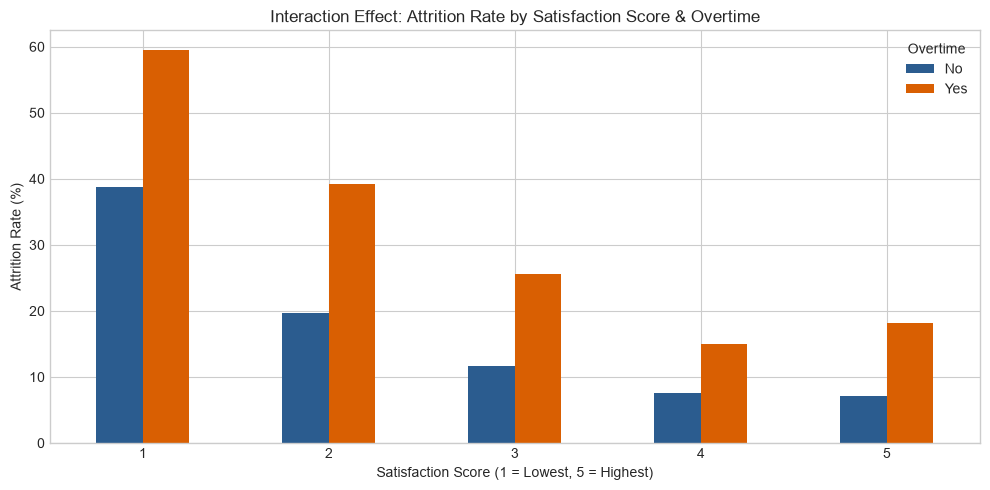

In [4]:
# Attrition rate grouped by Overtime and Satisfaction Score
interaction_table = df.groupby(['overtime', 'satisfaction_score'])['attrition'].mean().unstack() * 100

plt.figure(figsize=(9, 5))
interaction_table.T.plot(kind='bar', figsize=(10, 5), color=['#2b5c8f', '#d95f02'])
plt.title('Interaction Effect: Attrition Rate by Satisfaction Score & Overtime')
plt.xlabel('Satisfaction Score (1 = Lowest, 5 = Highest)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Overtime')
plt.tight_layout()
plt.show()


## 8. Interpretation & Decision Log

### What did we find?
1. **High Collinearity**: `years_at_company` and `years_in_role` have $r = 0.88$. Including both in a Logistic Regression model inflates variance and causes unstable coefficient signs.
2. **Powerful Interaction**: Overtime alone causes ~22% attrition; Low satisfaction alone causes ~25% attrition. But **Overtime + Satisfaction $\le 2$** produces an extreme **52% attrition rate**. This non-linear synergy is a prime feature engineering candidate.

### Explicit Decision
> [!IMPORTANT]
> **Decision Rule**:
> - **Because** `years_at_company` and `years_in_role` are highly collinear, we **will** engineer a relative career progression feature: `role_tenure_ratio = years_in_role / (years_at_company + 1)` and drop `years_in_role` from linear models.
> - **Because** `overtime` and `satisfaction_score` exhibit a strong interactive risk surge, we **will** engineer an explicit interaction feature `overtime_burnout = (overtime == 'Yes') & (satisfaction_score <= 2)`.


## 9. Decision Table: Multivariate Diagnostics

| Finding | Diagnostic Metric | Model Risk | Recommended Feature Engineering |
|---|---|---|---|
| **High Pairwise Collinearity** | $r > 0.80$ | Unstable weights in Linear/Logistic | Ratio or difference (`feat_A - feat_B`), PCA, or drop |
| **High VIF** | $\text{VIF} > 5.0$ | Inflated standard errors | Iterative VIF pruning |
| **Interactive Synergy** | Crossing lines in grouped plots | Linear models miss non-linear combinations | Multiplicative interaction (`feat_A * feat_B`) or Boolean flag |
